#Analytic Task 1: Passing Accuracy

# Analytic Question:
Is there a significant difference in passing accuracy between midfielders and forwards during the FIFA World Cup 2026?

This analytic task investigates whether the average passing accuracy of midfielders differs significantly from that of forwards during the FIFA World Cup 2026. The analysis compares two player groups: midfielders (MF) and forwards (FW). The numerical variable being investigated is passing accuracy (%), which represents the percentage of attempted passes successfully completed by a player.

 Player-level passing data will be obtained from the FIFA World Cup 2026 player statistics under the Distribution category. The FIFA dataset provides player positions and passing statistics required for this analysis. For example, players are identified by position such as MF and FW alongside their passing data.

# Data Wrangling

Player-level data for this analysis were obtained from the FIFA World Cup 2026 Player Statistics dataset under the Distribution category. The variables relevant to this analysis are Player, Country, Position, and Passing Accuracy (%).

Only players classified as midfielders (MF) or forwards (FW) are required because these are the two groups being compared. Other positions, such as defenders (DF) and goalkeepers (GK), will be excluded.

The dataset will be checked for duplicate records, missing values, and incorrect data types. Passing Accuracy (%) will be converted to a numeric variable where necessary so that it can be used for statistical analysis.

The FIFA data contains the required player positions and passing statistics. For example, Michael Olise is classified as a forward (FW) and has passing statistics recorded in the dataset.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving FIFA_World_Cup_2026_Q1_Data_Wrangling.xlsx to FIFA_World_Cup_2026_Q1_Data_Wrangling (2).xlsx


In [ ]:
import pandas as pd

df = pd.read_excel(
    "FIFA_World_Cup_2026_Q1_Data_Wrangling.xlsx",
    sheet_name="Raw_FIFA_Distribution"
)

df.head()

,Rank,Player,Passes,Passes\nCompleted,Passing\nAccuracy (%),Crosses,Crossing\nAccuracy (%),Take-Ons\nCompleted,Defensive\nLinebreaks Attempted,Defensive\nLinebreaks Acc (%),Switches of Play\nAttempted,Switches of Play\nAccuracy (%)
0,1,Rodri\nESP MF,799,747,93,3,0,2,21,90,11,91
1,2,Pau Cubarsi\nESP DF,690,668,97,1,0,0,7,71,2,100
2,3,Aymeric Laporte\nESP DF,660,618,94,0,0,0,12,58,8,100
3,4,Leandro Paredes\nARG MF,565,532,94,2,50,3,8,38,7,100
4,5,Marc Guehi\nENG DF,532,514,97,0,0,2,10,70,4,75


In [ ]:
# Check the size of the dataset
print("Dataset shape:", df.shape)

# Check column names
print("\nColumn names:")
print(df.columns.tolist())

# Check data types and missing values
print("\nDataset information:")
df.info()

Dataset shape: (1018, 12)

Column names:
['Rank', 'Player', 'Passes', 'Passes\nCompleted', 'Passing\nAccuracy (%)', 'Crosses', 'Crossing\nAccuracy (%)', 'Take-Ons\nCompleted', 'Defensive\nLinebreaks Attempted', 'Defensive\nLinebreaks Acc (%)', 'Switches of Play\nAttempted', 'Switches of Play\nAccuracy (%)']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1018 entries, 0 to 1017
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Rank                            1018 non-null   int64 
 1   Player                          1018 non-null   object
 2   Passes                          1018 non-null   int64 
 3   Passes
Completed                1018 non-null   int64 
 4   Passing
Accuracy (%)            1018 non-null   int64 
 5   Crosses                         1018 non-null   int64 
 6   Crossing
Accuracy (%)           1018 non-null   int64 
 7   Take-Ons
Complete

In [ ]:
# Replace line breaks in column names with spaces
df.columns = df.columns.str.replace("\n", " ", regex=False)

# Display cleaned column names
print(df.columns.tolist())

['Rank', 'Player', 'Passes', 'Passes Completed', 'Passing Accuracy (%)', 'Crosses', 'Crossing Accuracy (%)', 'Take-Ons Completed', 'Defensive Linebreaks Attempted', 'Defensive Linebreaks Acc (%)', 'Switches of Play Attempted', 'Switches of Play Accuracy (%)']


In [ ]:
# Extract country and position from the Player column
df["Country"] = df["Player"].str.extract(r'\n([A-Z]{3})')
df["Position"] = df["Player"].str.extract(r'\n[A-Z]{3}\s+(GK|DF|MF|FW)')

# Keep only the player's name
df["Player"] = df["Player"].str.split("\n").str[0]

# Display the result
df[["Player", "Country", "Position"]].head(10)

,Player,Country,Position
0,Rodri,ESP,MF
1,Pau Cubarsi,ESP,DF
2,Aymeric Laporte,ESP,DF
3,Leandro Paredes,ARG,MF
4,Marc Guehi,ENG,DF
5,Enzo Fernandez,ARG,MF
6,Ezri Konsa,ENG,DF
7,Manuel Akanji,SUI,DF
8,Marc Cucurella,ESP,DF
9,Granit Xhaka,SUI,MF


In [ ]:
# Keep only the columns needed for Question 1
q1_df = df[
    [
        "Player",
        "Country",
        "Position",
        "Passes",
        "Passes Completed",
        "Passing Accuracy (%)"
    ]
].copy()

# Keep only midfielders and forwards
q1_df = q1_df[q1_df["Position"].isin(["MF", "FW"])]

# Reset the index
q1_df = q1_df.reset_index(drop=True)

# Display the cleaned data
q1_df.head(10)

,Player,Country,Position,Passes,Passes Completed,Passing Accuracy (%)
0,Rodri,ESP,MF,799,747,93
1,Leandro Paredes,ARG,MF,565,532,94
2,Enzo Fernandez,ARG,MF,519,480,92
3,Granit Xhaka,SUI,MF,470,427,91
4,Pedri,ESP,MF,469,420,90
5,Elliot Anderson,ENG,MF,445,396,89
6,Neil El Aynaoui,MAR,MF,433,405,94
7,Alexis Mac Allister,ARG,MF,430,393,91
8,Sander Berge,NOR,MF,425,412,97
9,Michael Olise,FRA,FW,417,362,87


In [ ]:
# Check how many midfielders and forwards remain
print(q1_df["Position"].value_counts())
print("\nTotal players:", len(q1_df))

Position
MF    327
FW    286
Name: count, dtype: int64

Total players: 613


In [ ]:
# Check for missing values
print("Missing values:")
print(q1_df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", q1_df.duplicated().sum())

# Check for duplicate player names
print("Duplicate player names:", q1_df["Player"].duplicated().sum())

Missing values:
Player                  0
Country                 0
Position                0
Passes                  0
Passes Completed        0
Passing Accuracy (%)    0
dtype: int64

Duplicate rows: 0
Duplicate player names: 0


Data Wrangling Summary:
At first, there were 12 variables and 1,018 player records in the FIFA player distribution dataset. The Player field was divided into Player, Country, and Position variables, and column names were sanitised by eliminating line breaks. Due to their relevance to the analytical topic, only midfielders (MF) and forwards (FW) were kept. 327 midfielders and 286 attackers made up the 613 players in the final dataset. There were no missing values or duplicate records found in the cleaned dataset.

#Data Preparation and Sampling

The population for this analysis consists of the 613 midfielders and forwards in the FIFA World Cup 2026 dataset who have valid passing accuracy statistics. This includes 327 midfielders and 286 forwards.

Stratified random sampling will be used to ensure that both playing positions are represented in the sample. Players will first be separated according to position, and random samples will then be selected from the midfielder and forward groups.

A stratified random sample is taken separately from midfielders and forwards. Using 50 players from each group keeps the groups balanced and gives each group at least 30 observations, supporting the Central Limit Theorem for the later inferential analysis. A fixed random state is used so the sample is reproducible.


In [ ]:
# Separate midfielders and forwards
midfielders = q1_df[q1_df["Position"] == "MF"]
forwards = q1_df[q1_df["Position"] == "FW"]

# Randomly select 50 players from each group
mf_sample = midfielders.sample(n=50, random_state=42)
fw_sample = forwards.sample(n=50, random_state=42)

# Combine the two samples
sample_df = pd.concat([mf_sample, fw_sample])

# Reset the index
sample_df = sample_df.reset_index(drop=True)

# Display the sample
sample_df.head(10)

,Player,Country,Position,Passes,Passes Completed,Passing Accuracy (%)
0,Jesper Karlstrom,SWE,MF,37,31,84
1,Samir El Mourabet,MAR,MF,110,100,91
2,Carney Chukwuemeka,AUT,MF,30,25,83
3,Vitinha,POR,MF,403,379,94
4,Ryan Gravenberch,NED,MF,126,111,88
5,Fabinho,BRA,MF,43,42,98
6,Ala Alhajji,KSA,MF,17,16,94
7,Maxi Araujo,URU,MF,57,50,88
8,Chemsdine Talbi,MAR,MF,54,47,87
9,Otabek Shukurov,UZB,MF,117,103,88


In [ ]:
# Check the sample size
print("Total sample size:", len(sample_df))

# Check representation of each position
print("\nPlayers by position:")
print(sample_df["Position"].value_counts())

Total sample size: 100

Players by position:
Position
MF    50
FW    50
Name: count, dtype: int64


Sampling Method:
Stratified random sampling was used by dividing the population according to player position (MF and FW). A random sample of 50 midfielders and 50 forwards was selected, producing a total sample of 100 players. Equal sample sizes were used to provide balanced representation of the two groups for comparison. A fixed random state of 42 was used to make the sampling process reproducible.

In [ ]:
print("Total sample size:", len(sample_df))

print("\nSample by position:")
print(sample_df["Position"].value_counts())

Total sample size: 100

Sample by position:
Position
MF    50
FW    50
Name: count, dtype: int64


# Descriptive Statistics

Descriptive statistics are used to summarise and compare the passing accuracy of the sampled midfielders and forwards. The mean, median, standard deviation, minimum, maximum, and sample size are calculated for each position.

In [ ]:
# Calculate descriptive statistics for passing accuracy by position
descriptive_stats = sample_df.groupby("Position")["Passing Accuracy (%)"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

# Round results to 2 decimal places
descriptive_stats = descriptive_stats.round(2)

descriptive_stats

,count,mean,median,std,min,max
Position,,,,,,
FW,50,79.48,82.0,15.93,0,100
MF,50,84.94,88.0,12.64,33,100


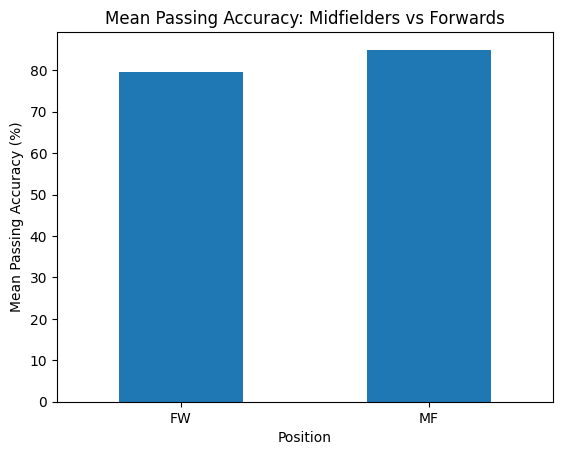

In [ ]:
import matplotlib.pyplot as plt

mean_accuracy = sample_df.groupby("Position")["Passing Accuracy (%)"].mean()

mean_accuracy.plot(kind="bar")

plt.title("Mean Passing Accuracy: Midfielders vs Forwards")
plt.xlabel("Position")
plt.ylabel("Mean Passing Accuracy (%)")
plt.xticks(rotation=0)
plt.show()

Interpretation:
The descriptive statistics show that the sampled midfielders had a higher mean passing accuracy (84.94%) than the sampled forwards (79.48%). The median passing accuracy was also higher for midfielders (88.00%) than forwards (82.00%). Forwards had a larger standard deviation (15.93) compared with midfielders (12.64), indicating greater variability in passing accuracy among the sampled forwards. Overall, the descriptive results suggest that midfielders had higher passing accuracy in the sample. However, inferential statistical analysis is required to determine whether this difference is statistically significant in the population.

# Inferential Statistics

A 95% confidence interval is calculated for the mean passing accuracy of midfielders and forwards. The confidence intervals provide a range of plausible values for the population mean passing accuracy of each playing position based on the sample data.

In [ ]:
# 95% confidence intervals using the CDU-taught method:
# sample mean ± 1.96 × (sample standard deviation / sqrt(n))

import numpy as np

def confidence_interval_95(data):
    n = len(data)
    mean = data.mean()
    std = data.std(ddof=1)
    standard_error = std / np.sqrt(n)
    margin_of_error = 1.96 * standard_error
    lower = mean - margin_of_error
    upper = mean + margin_of_error
    return lower, upper

mf_ci = confidence_interval_95(mf_sample["Passing Accuracy (%)"])
fw_ci = confidence_interval_95(fw_sample["Passing Accuracy (%)"])

print(f"Midfielders 95% CI: ({mf_ci[0]:.2f}%, {mf_ci[1]:.2f}%)")
print(f"Forwards 95% CI: ({fw_ci[0]:.2f}%, {fw_ci[1]:.2f}%)")


Midfielders 95% CI: (81.44%, 88.44%)
Forwards 95% CI: (75.06%, 83.90%)


#Inferential Statistics — Two-Sample t-Test

### State
Determine whether the population mean passing accuracy differs between midfielders and forwards.

### Plan
Let **μ_MF** be the population mean passing accuracy for midfielders and **μ_FW** the population mean passing accuracy for forwards.

- **H₀:** μ_MF = μ_FW
- **H₁:** μ_MF ≠ μ_FW
- Significance level: **α = 0.05**

A two-sample independent t-test is used because the analysis compares two independent groups.

### Solve
The samples were randomly selected within each position group. Each group contains 50 observations. The sample means and standard deviations are calculated before the t-statistic and p-value.

### Conclude
If **p ≤ 0.05**, reject H₀. If **p > 0.05**, fail to reject H₀. The conclusion should be stated in terms of whether there is sufficient statistical evidence of a difference in mean passing accuracy between midfielders and forwards.


In [ ]:
from scipy import stats

# Get passing accuracy values from the two samples
mf_accuracy = mf_sample["Passing Accuracy (%)"]
fw_accuracy = fw_sample["Passing Accuracy (%)"]

# Two-sample independent t-test
t_stat, p_value = stats.ttest_ind(
    mf_accuracy,
    fw_accuracy,
    equal_var=False
)

print(f"T-statistic = {t_stat:.4f}")
print(f"P-value = {p_value:.4f}")

# Decision at alpha = 0.05
alpha = 0.05

if p_value <= alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in mean passing accuracy.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in mean passing accuracy.")

T-statistic = 1.8981
P-value = 0.0608
Fail to reject the null hypothesis.
There is no statistically significant difference in mean passing accuracy.


Conclusion:
The analysis found that midfielders had a higher average passing accuracy than forwards in the selected sample. However, the two-sample t-test showed that this difference was not statistically significant at the 5% significance level (p = 0.0608). Therefore, based on this sample, there is insufficient evidence to conclude that midfielders and forwards have different mean passing accuracy in the FIFA World Cup 2026.